# Notebook 02 — Modelo de temperatura Alaton (OU + Fourier)


Extiende S12 Mean Reversion del curso con componente determinístico de Fourier.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Importar Datos

In [16]:
import pandas as pd

# Leer el excel
df = pd.read_excel('../data/simulated_climate_rice_2000_2025.xlsx')

# Ver columnas
print(df.columns)

# Seleccionar columnas de temperatura
temp = df[['Date',
           'Temperature_Avg_C',
           'Temperature_Min_C',
           'Temperature_Max_C']].copy()

# Convertir fecha
temp['Date'] = pd.to_datetime(temp['Date'])

# Ver primeros registros
print(temp.head())

#Indice temporal
temp['t'] = range(len(temp))

Index(['Date', 'Temperature_Avg_C', 'Temperature_Min_C', 'Temperature_Max_C',
       'Precipitation_mm'],
      dtype='object')
        Date  Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C
0 2000-01-01              24.81              18.82              29.24
1 2000-01-02              23.93              18.89              29.21
2 2000-01-03              25.18              18.93              29.21
3 2000-01-04              26.56              21.81              31.32
4 2000-01-05              23.99              20.50              28.12


## 2. Modelo Alaton

El modelo de Alaton et al. (2002) descompone la temperatura diaria en dos componentes: una parte determinística que captura la tendencia y estacionalidad anual, y una parte estocástica modelada mediante un proceso de reversión a la media tipo Ornstein-Uhlenbeck (OU). La estructura general es:

$$
T_t =
A + Bt +
C \sin\left(\frac{2\pi t}{365} + \phi\right)
+ X_t
$$

donde:
- $A$ representa el nivel promedio de temperatura,
- $Bt$ captura una posible tendencia temporal,
- el término sinusoidal representa la estacionalidad anual,
- y $X_t$ corresponde a las desviaciones aleatorias alrededor del comportamiento esperado.

En lugar de estimar directamente:

$$
C \sin\left(\frac{2\pi t}{365} + \phi\right)
$$

el modelo utiliza la forma equivalente:

$$
a \sin\left(\frac{2\pi t}{365}\right)
+
b \cos\left(\frac{2\pi t}{365}\right)
$$

ya que permite estimar linealmente la estacionalidad mediante OLS. Aquí, $\phi$ representa el desfase temporal del ciclo anual de temperatura.

Para facilitar la estimación mediante mínimos cuadrados ordinarios (OLS), la componente estacional se expresa usando funciones seno y coseno. De esta forma, el modelo final estimado es:

$$
T_t =
A + Bt +
a \sin\left(\frac{2\pi t}{365}\right)
+
b \cos\left(\frac{2\pi t}{365}\right)
+
X_t
$$

donde:
- $A$ representa el nivel promedio de temperatura,
- $Bt$ captura la tendencia temporal,
- $a$ y $b$ modelan la estacionalidad anual,
- y $X_t$ corresponde al componente estocástico de reversión a la media.

In [17]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# =========================================================
# CONSTRUCCIÓN DE TEMPERATURA PROMEDIO
# =========================================================

# Calcular temperatura promedio diaria usando Tmax y Tmin
temp['T_avg'] = (
    temp['Temperature_Max_C']
    + temp['Temperature_Min_C']
) / 2

# =========================================================
# COMPONENTE ESTACIONAL
# =========================================================

# Crear componente seno de la estacionalidad anual
temp['sin'] = np.sin(2 * np.pi * temp['t'] / 365)

# Crear componente coseno de la estacionalidad anual
temp['cos'] = np.cos(2 * np.pi * temp['t'] / 365)



### Estimación del componente determinístico

El componente determinístico se estima mediante mínimos cuadrados ordinarios (OLS), utilizando:
- una constante,
- una tendencia temporal,
- y las componentes estacionales seno y coseno.

El objetivo es aproximar el comportamiento climático esperado de la temperatura diaria.



In [18]:
# =========================================================
# ESTIMACIÓN DEL MODELO DETERMINÍSTICO
# =========================================================

# Definir temperatura promedio como variable dependiente
y = temp['T_avg']

# Definir variables explicativas
X = temp[['t', 'sin', 'cos']]

# Agregar intercepto
X = sm.add_constant(X)

# Ajustar modelo OLS
model = sm.OLS(y, X).fit()

# Mostrar resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  T_avg   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     8587.
Date:                Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                        21:28:09   Log-Likelihood:                -18620.
No. Observations:                9497   AIC:                         3.725e+04
Df Residuals:                    9493   BIC:                         3.728e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.0478      0.035    681.408      0.0

### Obtención de residuales

Una vez ajustado el modelo, se calculan los residuales:

$$
\epsilon_t =
T_t - \hat T_t
$$

Estos residuales representan anomalías térmicas respecto al patrón estacional esperado.


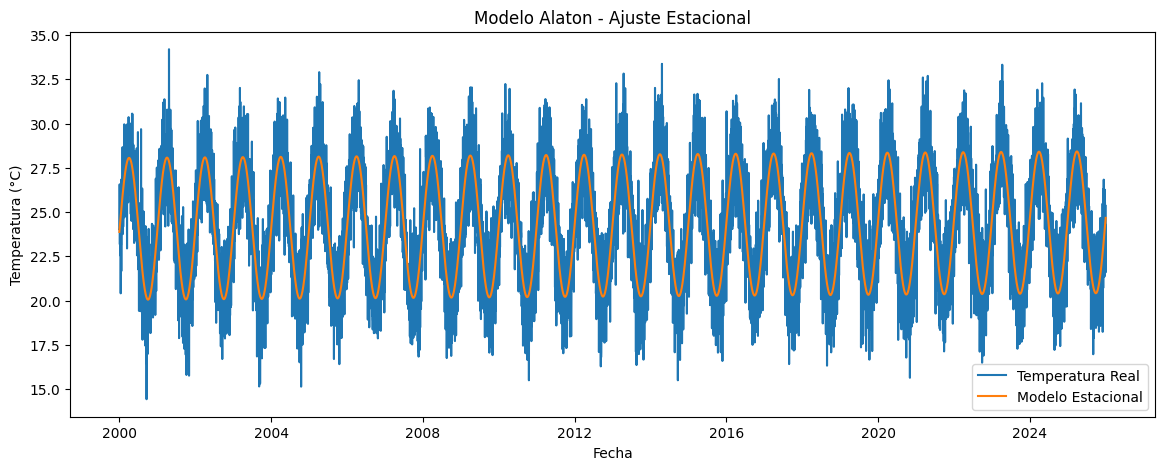

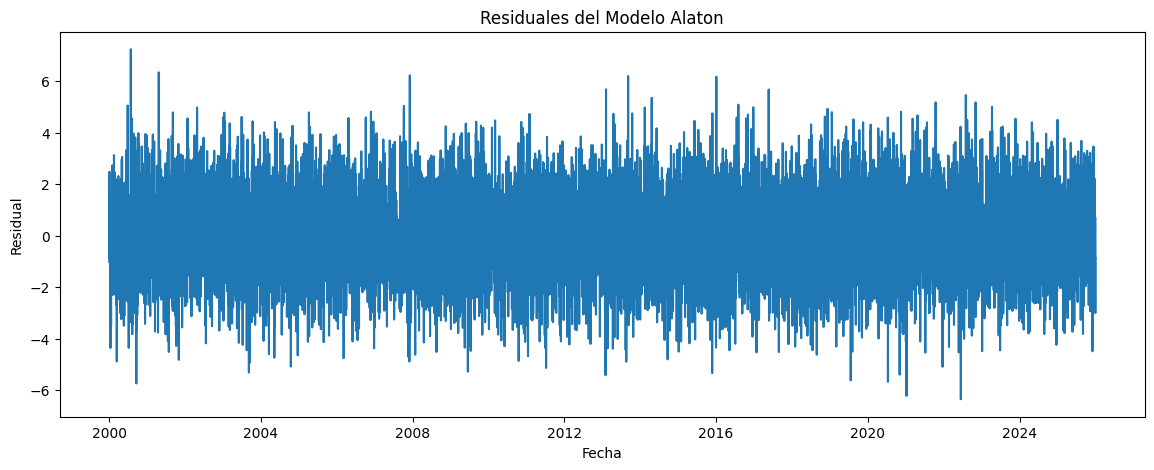

In [19]:
# =========================================================
# OBTENCIÓN DE RESIDUALES
# =========================================================

# Obtener temperatura ajustada
temp['seasonal_fit'] = model.predict(X)

# Calcular residuales
temp['residuals'] = (
    temp['T_avg']
    - temp['seasonal_fit']
)

# =========================================================
# GRÁFICA DEL AJUSTE ESTACIONAL
# =========================================================

# Graficar temperatura real y ajustada
plt.figure(figsize=(14,5))

plt.plot(
    temp['Date'],
    temp['T_avg'],
    label='Temperatura Real'
)

plt.plot(
    temp['Date'],
    temp['seasonal_fit'],
    label='Modelo Estacional'
)

plt.xlabel('Fecha')
plt.ylabel('Temperatura (°C)')
plt.title('Modelo Alaton - Ajuste Estacional')
plt.legend()

plt.show()

# =========================================================
# GRÁFICA DE RESIDUALES
# =========================================================

# Graficar residuales
plt.figure(figsize=(14,5))

plt.plot(
    temp['Date'],
    temp['residuals']
)

plt.xlabel('Fecha')
plt.ylabel('Residual')
plt.title('Residuales del Modelo Alaton')

plt.show()

### Modelado del componente estocástico

Los residuales se modelan mediante un proceso de reversión a la media tipo Ornstein-Uhlenbeck (OU), cuya discretización corresponde a un modelo AR(1):

$$
X_t =
\phi X_{t-1}
+
\eta_t
$$

A partir de este modelo se estiman:
- la persistencia temporal,
- la velocidad de reversión a la media,
- y la volatilidad del proceso climático.

In [20]:
# =========================================================
# MODELO AR(1) PARA RESIDUALES
# =========================================================

# Crear rezago de residuales
temp['res_lag'] = temp['residuals'].shift(1)

# Eliminar valores nulos
ou_data = temp.dropna().copy()

# Variable dependiente
y_ou = ou_data['residuals']

# Variable explicativa
X_ou = sm.add_constant(
    ou_data['res_lag']
)

# Ajustar modelo AR(1)
ou_model = sm.OLS(y_ou, X_ou).fit()

# Mostrar resultados
print(ou_model.summary())

# =========================================================
# PARÁMETROS DEL PROCESO OU
# =========================================================

# Obtener coeficiente AR(1)
phi = ou_model.params['res_lag']

# Calcular velocidad de reversión
kappa = -np.log(phi)

# Calcular volatilidad
sigma = np.std(ou_model.resid)

print("phi:", phi)
print("kappa:", kappa)
print("sigma:", sigma)

                            OLS Regression Results                            
Dep. Variable:              residuals   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.445
Date:                Fri, 22 May 2026   Prob (F-statistic):              0.229
Time:                        21:30:49   Log-Likelihood:                -18617.
No. Observations:                9496   AIC:                         3.724e+04
Df Residuals:                    9494   BIC:                         3.725e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.689e-05      0.018     -0.001      0.9

C:\Users\jhoan\AppData\Local\Temp\ipykernel_26116\2273859145.py:33: RuntimeWarning: invalid value encountered in log
  kappa = -np.log(phi)
